<a href="https://colab.research.google.com/github/zhiyuguo-innis/MSSP607/blob/main/zhiyuguo-innis/MSSP607/Assignments/Case_Study_Assignment1_Analysis_UPDATED_RADAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case 1

**Student:** Zhiyu Guo  
**Dataset:** *Data of Academic Performance Evolution for Engineering Students* (De La Hoz, 2020)

## 1. Setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 60)
DATA_PATH = 'data_academic_performance.xlsx'
# In Google Colab, upload the data file first if it is not already in the working folder.
if not os.path.exists(DATA_PATH):
    from google.colab import files
    files.upload()  # select data_academic_performance.xlsx
df = pd.read_excel(DATA_PATH, sheet_name='SABER11_SABERPRO')
# Remove the blank column that appears in the source workbook, if present.
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]
print('Shape:', df.shape)
df.head()

I removed the empty column because it contained no data.

## 2. Data quality and descriptive overview

In [ ]:
numeric_cols = ['MAT_S11','CR_S11','CC_S11','BIO_S11','ENG_S11',
                'QR_PRO','CR_PRO','CC_PRO','ENG_PRO','WC_PRO','FEP_PRO','G_SC']
print(df[numeric_cols].describe().T.round(2))

for c in ['GENDER','EDU_FATHER','EDU_MOTHER','STRATUM','REVENUE','INTERNET','SCHOOL_NAT']:
    print('\n', c)
    print(df[c].value_counts(dropna=False))

           count    mean    std   min    25%    50%    75%    max
MAT_S11  12411.0   64.32  11.87  26.0   56.0   64.0   72.0  100.0
CR_S11   12411.0   60.78  10.03  24.0   54.0   61.0   67.0  100.0
CC_S11   12411.0   60.71  10.12   0.0   54.0   60.0   67.0  100.0
BIO_S11  12411.0   63.95  11.16  11.0   56.0   64.0   71.0  100.0
ENG_S11  12411.0   61.80  14.30  26.0   50.0   59.0   72.0  100.0
QR_PRO   12411.0   77.42  22.67   1.0   65.0   85.0   96.0  100.0
CR_PRO   12411.0   62.20  27.67   1.0   42.0   67.0   86.0  100.0
CC_PRO   12411.0   59.19  28.99   1.0   36.0   65.0   85.0  100.0
ENG_PRO  12411.0   67.50  25.50   1.0   51.0   74.0   88.0  100.0
WC_PRO   12411.0   53.70  30.00   0.0   28.0   56.0   80.0  100.0
FEP_PRO  12411.0  145.48  40.13   1.0  124.0  153.0  174.0  300.0
G_SC     12411.0  162.71  23.11  37.0  147.0  163.0  179.0  247.0

 GENDER
GENDER
M    7368
F    5043
Name: count, dtype: int64

 EDU_FATHER
EDU_FATHER
Complete professional education          3016
Complete S

In [ ]:
edu_order = ['Ninguno','Incomplete primary ','Complete primary ','Incomplete Secundary',
             'Complete Secundary','Incomplete technical or technological',
             'Complete technique or technology','Incomplete Professional Education',
             'Complete professional education','Postgraduate education']
stratum_order = [f'Stratum {i}' for i in range(1,7)]
revenue_order = ['less than 1 LMMW','Between 1 and less than 2 LMMW',
                 'Between 2 and less than 3 LMMW','Between 3 and less than 5 LMMW',
                 'Between 5 and less than 7 LMMW','Between 7 and less than 10 LMMW',
                 '10 or more LMMW']

def grouped_summary(data, group, value='G_SC', order=None):
    out = data.groupby(group)[value].agg(['count','mean','median','std'])
    if order is not None:
        out = out.reindex([x for x in order if x in out.index])
    return out.round(2)

def eta_squared_anova(data, group, value='G_SC'):
    groups = [g[value].dropna().values for _, g in data.groupby(group)]
    F, p = stats.f_oneway(*groups)
    y = data[value].dropna()
    grand = y.mean()
    ss_between = sum(len(g)*(np.mean(g)-grand)**2 for g in groups)
    ss_total = ((y-grand)**2).sum()
    return F, p, ss_between/ss_total

def cohens_d(a,b):
    a,b=np.asarray(a),np.asarray(b)
    pooled=np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
    return (a.mean()-b.mean())/pooled

Eta squared and Cohen's d measure the size of group differences, while ANOVA and t-test p-values assess statistical significance.

## 3. Question 1 - Does parental education influence outcomes?

I compared G_SC across parental education levels, leaving out entries marked '0' or 'Not sure'. I calculated each group's count, mean, median, and standard deviation, then used ANOVA and eta squared to assess the differences.

In [ ]:
m = df[~df['EDU_MOTHER'].isin(['0','Not sure'])].copy()
f = df[~df['EDU_FATHER'].isin(['0','Not sure'])].copy()

print("Mother's education")
display(grouped_summary(m,'EDU_MOTHER',order=edu_order))
print("Father's education")
display(grouped_summary(f,'EDU_FATHER',order=edu_order))

Fm, pm, eta_m = eta_squared_anova(m,'EDU_MOTHER')
Ff, pf, eta_f = eta_squared_anova(f,'EDU_FATHER')
print(f"Mother: F={Fm:.2f}, p={pm:.3e}, eta^2={eta_m:.3f}")
print(f"Father: F={Ff:.2f}, p={pf:.3e}, eta^2={eta_f:.3f}")

Mother's education


,count,mean,median,std
EDU_MOTHER,,,,
Ninguno,34,149.71,152.5,27.93
Incomplete primary,541,154.85,155.0,21.64
Complete primary,713,155.34,155.0,22.01
Incomplete Secundary,1056,155.67,156.0,21.93
Complete Secundary,3106,158.47,159.0,21.95
Incomplete technical or technological,341,161.88,164.0,20.74
Complete technique or technology,1495,163.24,163.0,21.94
Incomplete Professional Education,502,166.69,168.0,22.93
Complete professional education,3059,168.85,170.0,22.98


Father's education


,count,mean,median,std
EDU_FATHER,,,,
Ninguno,123,156.63,159.0,23.19
Incomplete primary,735,155.73,156.0,20.94
Complete primary,824,155.20,155.0,22.41
Incomplete Secundary,1091,156.54,157.0,21.74
Complete Secundary,2843,158.79,159.0,22.11
Incomplete technical or technological,277,162.10,162.0,21.88
Complete technique or technology,1194,164.03,164.0,22.17
Incomplete Professional Education,425,166.92,168.0,22.69
Complete professional education,3016,167.77,169.0,23.03


Mother: F=101.60, p=2.368e-203, eta^2=0.077
Father: F=102.04, p=4.473e-204, eta^2=0.078


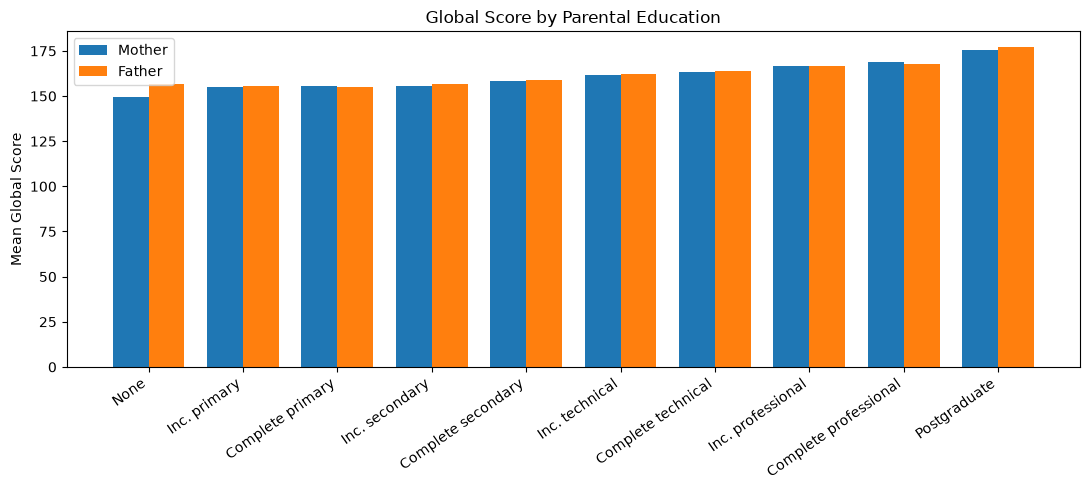

In [ ]:
mother_means = grouped_summary(m,'EDU_MOTHER',order=edu_order)['mean']
father_means = grouped_summary(f,'EDU_FATHER',order=edu_order)['mean']
x=np.arange(len(mother_means)); w=.38
plt.figure(figsize=(11,5))
plt.bar(x-w/2,mother_means,w,label="Mother")
plt.bar(x+w/2,father_means,w,label="Father")
plt.xticks(x,['None','Inc. primary','Complete primary','Inc. secondary','Complete secondary',
              'Inc. technical','Complete technical','Inc. professional','Complete professional','Postgraduate'],
           rotation=35,ha='right')
plt.ylabel('Mean Global Score')
plt.title('Global Score by Parental Education')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Question 2 - Which socioeconomic stratum performs best?

I compared all 12 scores across STRATUM groups 1-6, leaving out records with unknown STRATUM. I calculated group means and sample sizes, identified the highest average for each score, and used ANOVA and eta squared to assess the differences. The radar chart shows these averages on a common 0-100 scale.

In [ ]:
# All score columns: five S11 scores, six PRO scores, and Global Score.
score_cols = numeric_cols.copy()
s = df[df['STRATUM'].isin(stratum_order)].copy()
stratum_means = s.groupby('STRATUM')[score_cols].mean().reindex(stratum_order)
stratum_counts = s.groupby('STRATUM')[score_cols].count().reindex(stratum_order)
print('Mean scores by stratum (original units)')
display(stratum_means.round(2))
print('Valid sample sizes by stratum and score')
display(stratum_counts)

# Holm adjustment controls family-wise error over the 12 score tests.
def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    adjusted[order] = np.minimum(1, np.maximum.accumulate(
        p_values[order] * np.arange(len(p_values), 0, -1)))
    return adjusted

rows = []
for metric in score_cols:
    means = stratum_means[metric].dropna()
    winners = ', '.join(means.index[means == means.max()])
    F, p, eta = eta_squared_anova(s, 'STRATUM', metric)
    rows.append([metric, winners, means.max(), means.max() - means.min(), F, p, eta])
stratum_results = pd.DataFrame(rows, columns=[
    'Metric', 'Highest mean stratum', 'Highest mean', 'Highest-lowest mean gap',
    'ANOVA F', 'ANOVA p', 'Eta squared']).set_index('Metric')
stratum_results['Holm p'] = holm_adjust(stratum_results['ANOVA p'])
print('Highest observed mean and overall group comparison for every score')
display(stratum_results.style.format({
    'Highest mean': '{:.2f}', 'Highest-lowest mean gap': '{:.2f}',
    'ANOVA F': '{:.2f}', 'ANOVA p': '{:.3e}', 'Eta squared': '{:.3f}',
    'Holm p': '{:.3e}'}))

Mean scores by stratum (original units)


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC
STRATUM,,,,,,,,,,,,
Stratum 1,59.85,57.08,57.27,60.23,53.43,70.52,53.57,50.92,50.91,49.30,142.98,152.35
Stratum 2,62.08,59.12,59.21,62.10,57.21,74.62,58.82,55.96,60.95,51.15,142.48,158.20
Stratum 3,64.34,61.48,61.30,63.96,62.38,78.34,63.86,60.15,70.62,53.04,142.20,163.82
Stratum 4,69.11,64.06,63.58,67.70,69.83,83.22,69.27,66.97,80.10,59.59,154.05,172.00
Stratum 5,72.13,65.49,64.88,71.02,77.02,86.70,71.75,69.23,87.00,63.66,160.42,177.39
Stratum 6,74.67,66.01,66.67,72.67,82.38,88.36,73.76,71.07,92.45,65.59,162.17,181.51


Valid sample sizes by stratum and score


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC
STRATUM,,,,,,,,,,,,
Stratum 1,1709,1709,1709,1709,1709,1709,1709,1709,1709,1709,1709,1709
Stratum 2,4029,4029,4029,4029,4029,4029,4029,4029,4029,4029,4029,4029
Stratum 3,4045,4045,4045,4045,4045,4045,4045,4045,4045,4045,4045,4045
Stratum 4,1578,1578,1578,1578,1578,1578,1578,1578,1578,1578,1578,1578
Stratum 5,633,633,633,633,633,633,633,633,633,633,633,633
Stratum 6,403,403,403,403,403,403,403,403,403,403,403,403


Highest observed mean and overall group comparison for every score


,Highest mean stratum,Highest mean,Highest-lowest mean gap,ANOVA F,ANOVA p,Eta squared,Holm p
Metric,,,,,,,
MAT_S11,Stratum 6,74.67,14.82,271.08,5.529e-276,0.099,4.976e-275
CR_S11,Stratum 6,66.01,8.93,166.69,4.050e-172,0.063,2.835e-171
CC_S11,Stratum 6,66.67,9.41,142.57,1.474e-147,0.054,8.845e-147
BIO_S11,Stratum 6,72.67,12.44,212.52,3.383e-218,0.079,2.706e-217
ENG_S11,Stratum 6,82.38,28.95,810.85,0.000e+00,0.247,0.000e+00
QR_PRO,Stratum 6,88.36,17.84,110.69,8.701e-115,0.043,4.350e-114
CR_PRO,Stratum 6,73.76,20.20,101.93,1.026e-105,0.040,4.104e-105
CC_PRO,Stratum 6,71.07,20.16,93.57,4.815e-97,0.036,1.444e-96
ENG_PRO,Stratum 6,92.45,41.54,532.47,0.000e+00,0.177,0.000e+00


### STRATUM radar chart - all 12 scores

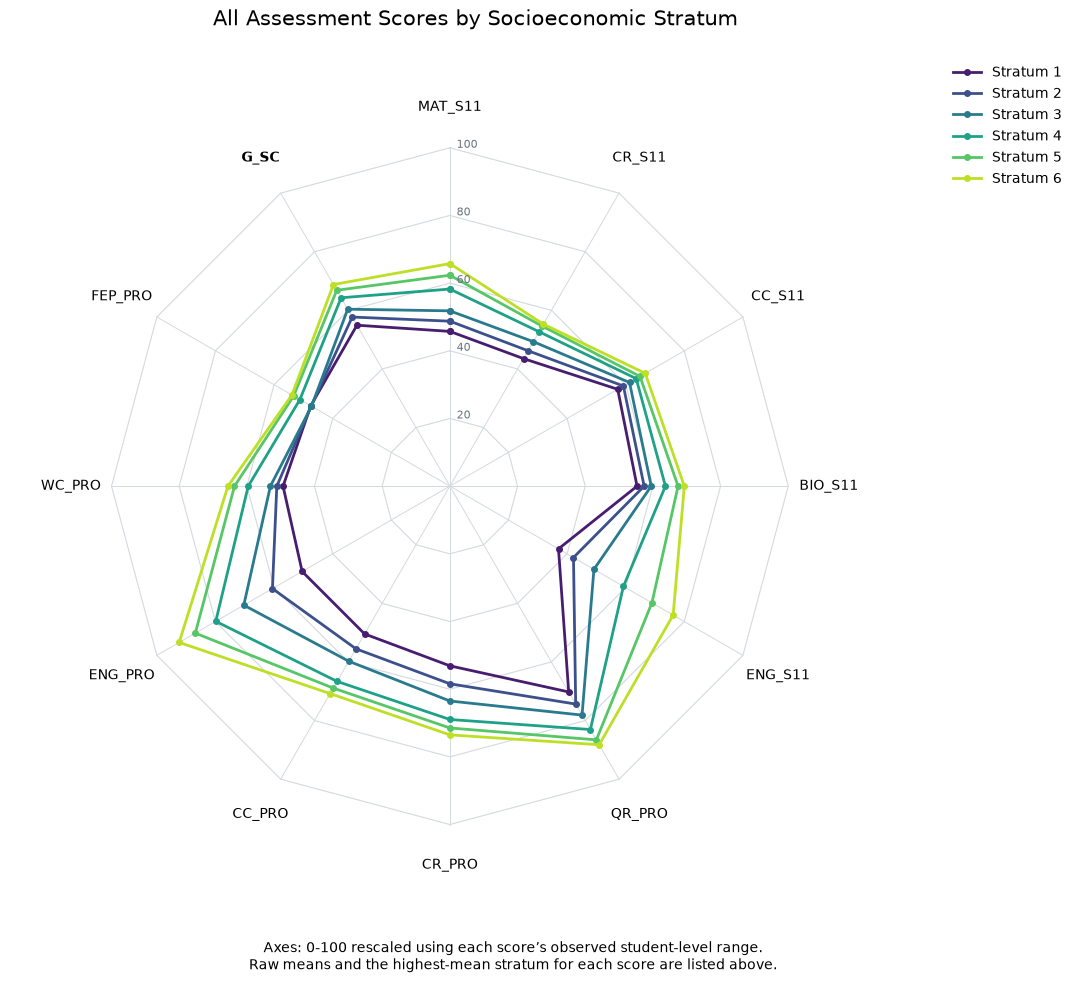

In [ ]:
score_min = df[score_cols].min()
score_range = (df[score_cols].max() - score_min).replace(0, np.nan)
radar_values = 100 * (stratum_means - score_min) / score_range

# Draw a regular 12-sided polygon frame and polygon grid rings.
angles = np.pi / 2 - np.arange(len(score_cols)) * 2 * np.pi / len(score_cols)
directions = np.column_stack([np.cos(angles), np.sin(angles)])
fig, ax = plt.subplots(figsize=(12, 10))
for radius in [20, 40, 60, 80, 100]:
    ring = directions * radius
    ring = np.vstack([ring, ring[0]])
    ax.plot(ring[:, 0], ring[:, 1], color='#d4d9df', linewidth=0.8, zorder=0)
    ax.text(2, radius, str(radius), fontsize=8, color='#68717d')
for metric, direction in zip(score_cols, directions):
    ax.plot([0, 100 * direction[0]], [0, 100 * direction[1]],
            color='#d4d9df', linewidth=0.7, zorder=0)
    ax.text(*(direction * 112), metric, ha='center', va='center', fontsize=10,
            fontweight='bold' if metric == 'G_SC' else 'normal')
colors = plt.cm.viridis(np.linspace(0.08, 0.9, len(stratum_order)))
for (stratum, values), color in zip(radar_values.iterrows(), colors):
    vertices = directions * values.to_numpy()[:, None]
    vertices = np.vstack([vertices, vertices[0]])
    ax.plot(vertices[:, 0], vertices[:, 1], label=stratum, color=color,
            linewidth=2, marker='o', markersize=4)
ax.set_aspect('equal')
ax.set_xlim(-130, 145)
ax.set_ylim(-128, 128)
ax.axis('off')
ax.set_title('All Assessment Scores by Socioeconomic Stratum', pad=20, fontsize=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), frameon=False)
fig.text(0.5, 0.025, 'Axes: 0-100 rescaled using each score’s observed student-level range.\n'
         'Raw means and the highest-mean stratum for each score are listed above.',
         ha='center', fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


## 5. Question 3 - How does each gender perform?

I compared male and female results for all 12 scores, including G_SC, using the available scores in each group. I calculated sample sizes, means, standard deviations, and mean differences, then used Welch's t-test and Cohen's d to assess the differences.

In [ ]:
metrics = numeric_cols.copy()
rows_out = []
for metric in metrics:
    male = df.loc[df.GENDER == 'M', metric].dropna()
    female = df.loc[df.GENDER == 'F', metric].dropna()
    t, p = stats.ttest_ind(male, female, equal_var=False)
    rows_out.append([metric, len(male), len(female), male.mean(), female.mean(),
                     male.std(), female.std(), male.mean() - female.mean(),
                     p, cohens_d(male, female)])
gender_table = pd.DataFrame(rows_out, columns=[
    'Metric', 'Male n', 'Female n', 'Male mean', 'Female mean',
    'Male std', 'Female std', 'M-F difference', 'Welch p', 'Cohen d']).set_index('Metric')
gender_table['Holm p'] = holm_adjust(gender_table['Welch p'])
display(gender_table.style.format({
    **{c: '{:.2f}' for c in ['Male mean', 'Female mean', 'Male std', 'Female std', 'M-F difference']},
    'Welch p': '{:.3e}', 'Holm p': '{:.3e}', 'Cohen d': '{:.3f}'}))
g = gender_table.loc['G_SC']
print(f"Global Score: male mean = {g['Male mean']:.2f}, female mean = {g['Female mean']:.2f}; "
      f"male-female difference = {g['M-F difference']:.2f}; Cohen's d = {g['Cohen d']:.3f}; "
      f"Welch p = {g['Welch p']:.3e}, Holm p = {g['Holm p']:.3e}.")


,Male n,Female n,Male mean,Female mean,Male std,Female std,M-F difference,Welch p,Cohen d,Holm p
Metric,,,,,,,,,,
MAT_S11,7368,5043,65.96,61.93,12.06,11.17,4.02,7.416e-80,0.344,8.158e-79
CR_S11,7368,5043,60.70,60.90,10.13,9.87,-0.20,2.803e-01,-0.020,5.607e-01
CC_S11,7368,5043,61.22,59.96,10.48,9.52,1.26,4.670e-12,0.124,3.736e-11
BIO_S11,7368,5043,65.10,62.27,11.43,10.53,2.83,1.663e-45,0.256,1.663e-44
ENG_S11,7368,5043,62.04,61.45,14.63,13.79,0.59,2.254e-02,0.041,9.017e-02
QR_PRO,7368,5043,81.20,71.89,20.80,24.12,9.31,1.590e-107,0.419,1.908e-106
CR_PRO,7368,5043,62.79,61.34,27.89,27.32,1.45,3.998e-03,0.052,1.999e-02
CC_PRO,7368,5043,59.61,58.57,29.70,27.92,1.03,4.870e-02,0.036,1.461e-01
ENG_PRO,7368,5043,68.16,66.53,25.97,24.76,1.63,4.254e-04,0.064,2.552e-03


Global Score: male mean = 163.69, female mean = 161.28; male-female difference = 2.41; Cohen's d = 0.105; Welch p = 7.785e-09, Holm p = 5.450e-08.


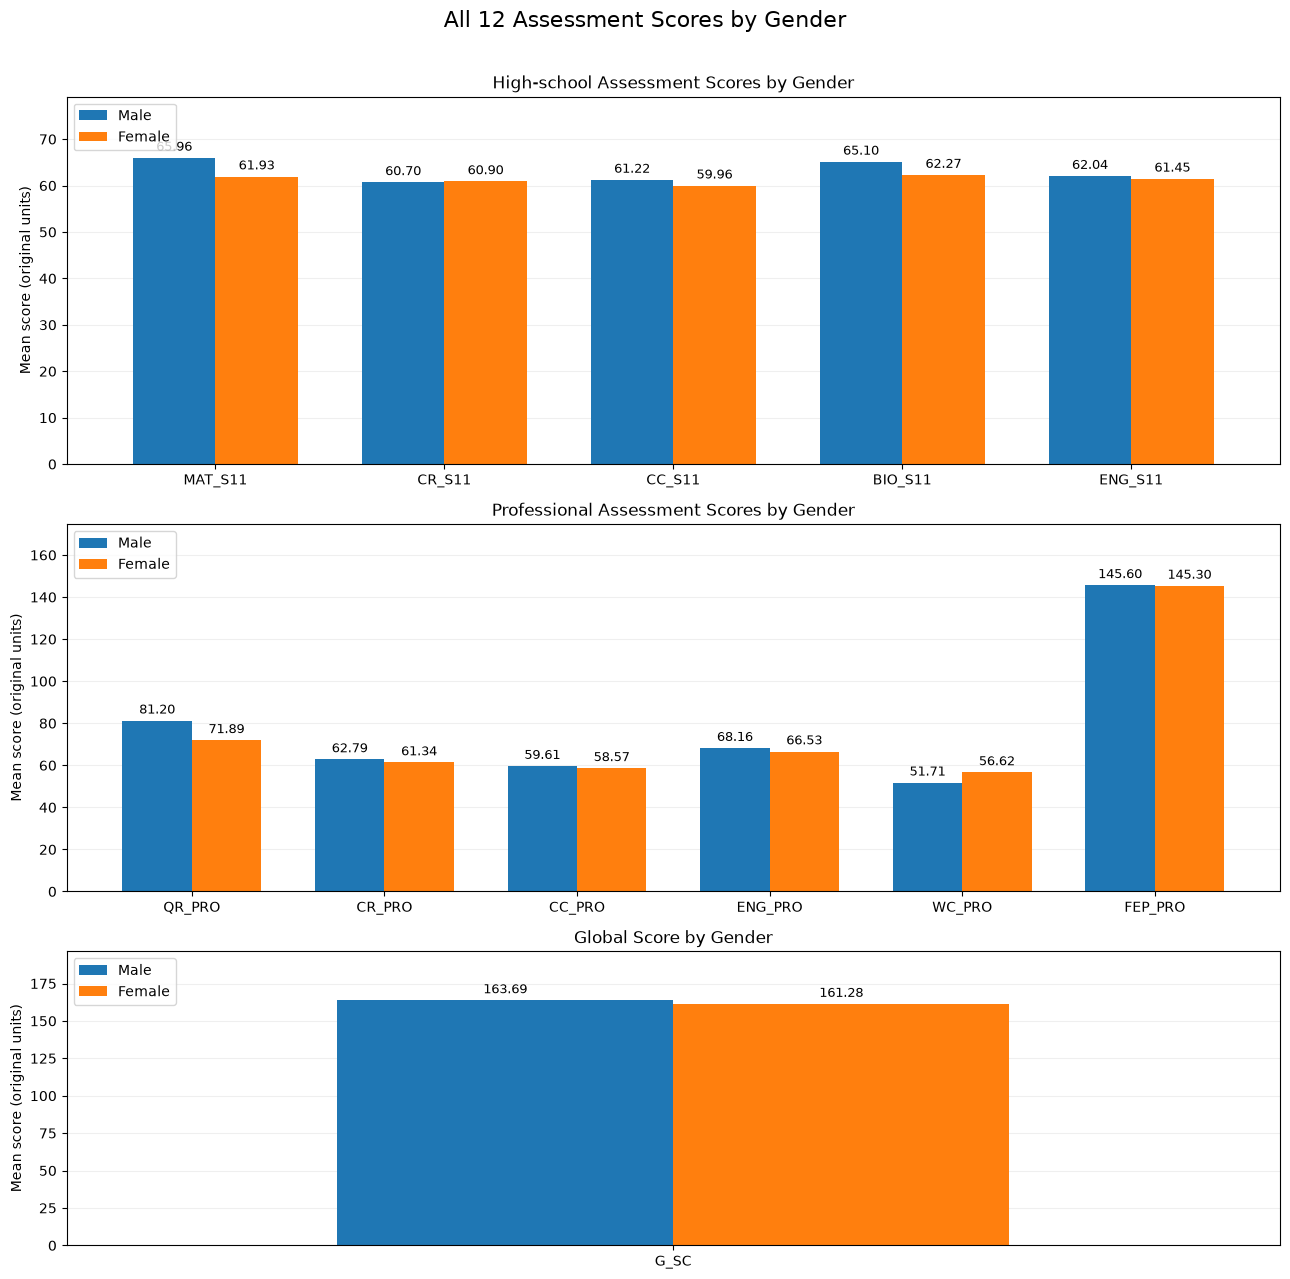

In [ ]:
# Preserve paired male/female bars and show every score, including G_SC.
panels = [
    ('High-school Assessment Scores by Gender', metrics[:5]),
    ('Professional Assessment Scores by Gender', metrics[5:11]),
    ('Global Score by Gender', ['G_SC'])
]
fig, axes = plt.subplots(3, 1, figsize=(13, 13), gridspec_kw={'height_ratios': [1, 1, 0.8]})
for ax, (title, plot_metrics) in zip(axes, panels):
    x = np.arange(len(plot_metrics))
    w = 0.36
    male_bars = ax.bar(x-w/2, gender_table.loc[plot_metrics, 'Male mean'], w,
                       label='Male', color='tab:blue')
    female_bars = ax.bar(x+w/2, gender_table.loc[plot_metrics, 'Female mean'], w,
                         label='Female', color='tab:orange')
    ax.bar_label(male_bars, fmt='%.2f', padding=3, fontsize=9)
    ax.bar_label(female_bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_xticks(x, plot_metrics)
    ax.set_ylabel('Mean score (original units)')
    ax.set_title(title)
    highest = gender_table.loc[plot_metrics, ['Male mean', 'Female mean']].to_numpy().max()
    ax.set_ylim(0, highest * 1.2)
    ax.set_xlim(-0.65, len(plot_metrics)-0.35)
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left')
fig.suptitle('All 12 Assessment Scores by Gender', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 6. Additional social and institutional comparisons

In [ ]:
# Household revenue
r = df[df.REVENUE!='0'].copy()
display(grouped_summary(r,'REVENUE',order=revenue_order))
Fr, pr, eta_r = eta_squared_anova(r,'REVENUE')
print(f"Revenue ANOVA: F={Fr:.2f}, p={pr:.3e}, eta^2={eta_r:.3f}")

# Internet access and school nature
for col,a,b in [('INTERNET','Yes','No'),('SCHOOL_NAT','PRIVATE','PUBLIC')]:
    A=df.loc[df[col]==a,'G_SC'].dropna(); B=df.loc[df[col]==b,'G_SC'].dropna()
    t,p=stats.ttest_ind(A,B,equal_var=False)
    print(f"{col}: {a} mean={A.mean():.2f}, {b} mean={B.mean():.2f}, difference={A.mean()-B.mean():.2f}, p={p:.3e}, d={cohens_d(A,B):.3f}")

,count,mean,median,std
REVENUE,,,,
less than 1 LMMW,1037,153.31,153.0,22.01
Between 1 and less than 2 LMMW,3873,156.77,157.0,22.05
Between 2 and less than 3 LMMW,2783,160.94,162.0,21.63
Between 3 and less than 5 LMMW,2239,165.34,167.0,22.08
Between 5 and less than 7 LMMW,973,170.86,172.0,21.79
Between 7 and less than 10 LMMW,509,176.18,178.0,19.96
10 or more LMMW,718,183.67,185.0,20.72


Revenue ANOVA: F=222.12, p=3.136e-312, eta^2=0.111
INTERNET: Yes mean=164.92, No mean=154.62, difference=10.30, p=7.123e-94, d=0.453
SCHOOL_NAT: PRIVATE mean=168.22, PUBLIC mean=156.53, difference=11.69, p=1.527e-180, d=0.523


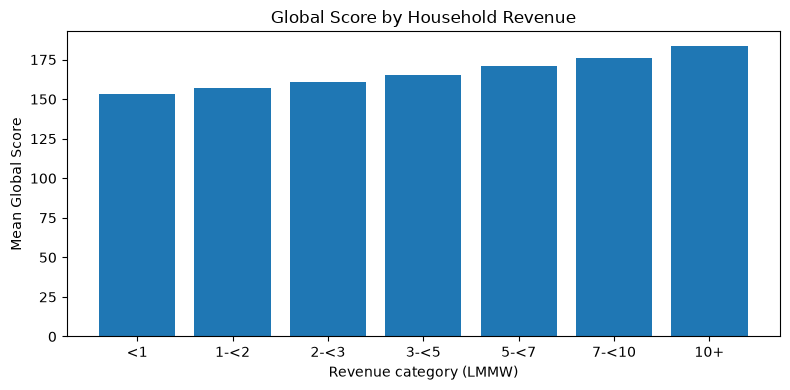

In [ ]:
rev_means=grouped_summary(r,'REVENUE',order=revenue_order)['mean']
plt.figure(figsize=(8,4))
plt.bar(range(len(rev_means)),rev_means)
plt.xticks(range(len(rev_means)),['<1','1-<2','2-<3','3-<5','5-<7','7-<10','10+'])
plt.xlabel('Revenue category (LMMW)'); plt.ylabel('Mean Global Score'); plt.title('Global Score by Household Revenue')
plt.tight_layout(); plt.show()